In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data = pd.read_csv("../data/adult.data", index_col=False, names=['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','gender','capital_gain','capital_loss','hours_per_week','native_country', 'income'])
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
data.shape

(32561, 15)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   gender          32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
gender            0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [6]:
data['age'].unique()

array([39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 30, 23, 32, 40, 34, 25, 43,
       54, 35, 59, 56, 19, 20, 45, 22, 48, 21, 24, 57, 44, 41, 29, 18, 47,
       46, 36, 79, 27, 67, 33, 76, 17, 55, 61, 70, 64, 71, 68, 66, 51, 58,
       26, 60, 90, 75, 65, 77, 62, 63, 80, 72, 74, 69, 73, 81, 78, 88, 82,
       83, 84, 85, 86, 87], dtype=int64)

In [7]:
for col in data.columns:
    print(f'{col}:\n',data[col].unique())

age:
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass:
 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
fnlwgt:
 [ 77516  83311 215646 ...  34066  84661 257302]
education:
 [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
education_num:
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital_status:
 [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation:
 [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishin

In workclass, occupation, native_country, there is anonymous value '?'. We have to replace this value.

In [8]:
df = data.copy()

In [9]:
## Removing leading spaces from object columns
obj_cols = df.select_dtypes(include='object')
df[obj_cols.columns] = obj_cols.apply(lambda x:x.str.lstrip()) 

In [10]:
for col in ['workclass','occupation','native_country']:
    print(f'{col}:',df[df[col] == ' ?'].shape[0])

workclass: 0
occupation: 0
native_country: 0


In [11]:
df[df['occupation']=='?']['workclass'].value_counts()

workclass
?               1836
Never-worked       7
Name: count, dtype: int64

In [12]:
df[df['occupation']=='?']['native_country'].value_counts().head()

native_country
United-States    1666
Mexico             33
?                  27
Canada             14
Philippines        10
Name: count, dtype: int64

Instead of imputing missing values '?', we encode them as 'Unknown'to preserve missingness as distinct category.

In [13]:
for col in ['workclass', 'occupation','native_country']:
    df[col].replace('?', 'Unknown', inplace=True)

In [14]:
for col in ['workclass', 'occupation','native_country']:
    print(f'{col}:\n', df[col].unique())

workclass:
 ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Unknown' 'Self-emp-inc' 'Without-pay' 'Never-worked']
occupation:
 ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Unknown'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
native_country:
 ['United-States' 'Cuba' 'Jamaica' 'India' 'Unknown' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 

In [16]:
num_features = df.select_dtypes(exclude='object').columns
cat_features = df.select_dtypes(include='object').columns

In [17]:
numeric_transformer = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('obj', categorical_transformer, cat_features)
])


In [18]:
preprocessor1.fit_transform(df)

array([[39.0, 77516.0, 13.0, ..., 'Male', 'United-States', '<=50K'],
       [50.0, 83311.0, 13.0, ..., 'Male', 'United-States', '<=50K'],
       [38.0, 215646.0, 9.0, ..., 'Male', 'United-States', '<=50K'],
       ...,
       [58.0, 151910.0, 9.0, ..., 'Female', 'United-States', '<=50K'],
       [22.0, 201490.0, 9.0, ..., 'Male', 'United-States', '<=50K'],
       [52.0, 287927.0, 9.0, ..., 'Female', 'United-States', '>50K']],
      dtype=object)

In [19]:
df.describe(exclude='object')

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


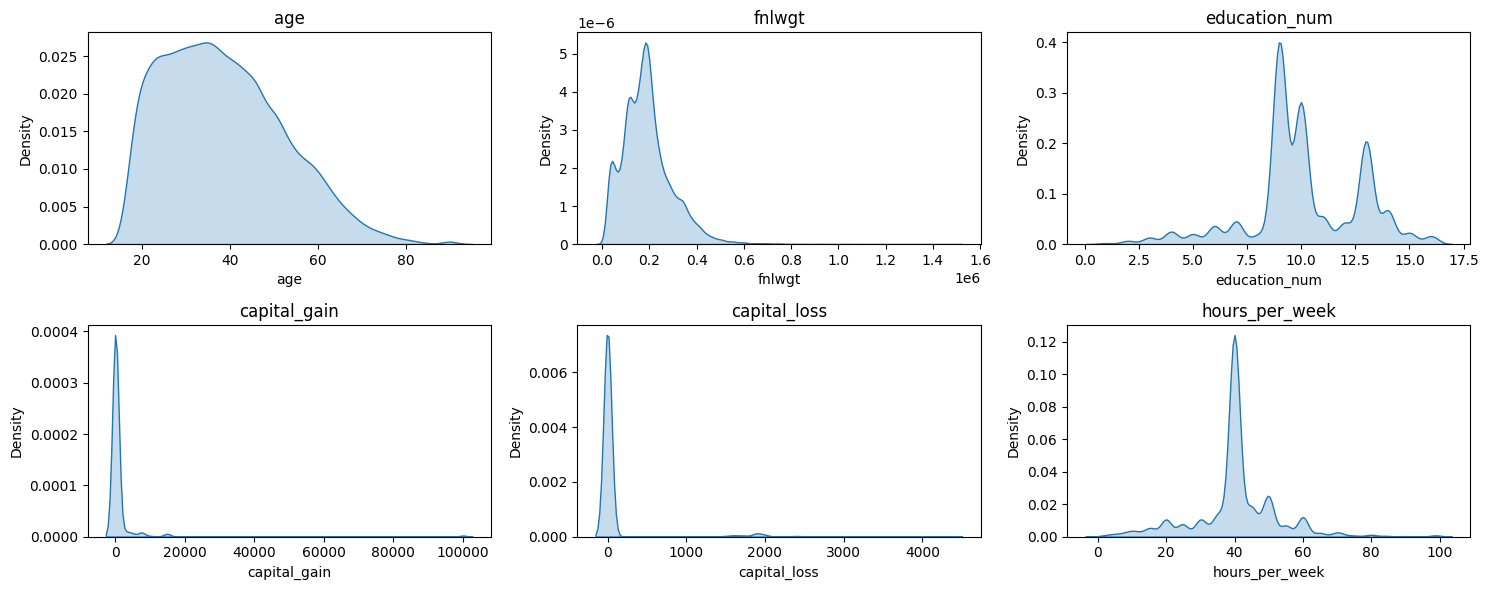

In [20]:
num_cols = df.select_dtypes(exclude='object').columns
fig,ax = plt.subplots(2,3,figsize=(15,6))
ax = ax.flatten()

for i, col in enumerate(num_cols[:6]): 
    sns.kdeplot(data=df, x=col, ax=ax[i], fill=True)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

Age is slightly positively skewed, indicating most individuals are younger. Capital-gain and capital-loss are highly skewed, with most individuals having zero gain and loss. Working hours are concentrated around 40 hours per week. Higher education levels (Bachelors and above) are less common and large portion of the population has education up to high school (HS-grad)

In [21]:
outlier_summary = {'feature':[], 'lower_bound': [], 'upper_bound': [],'outliers':[], 'outlier_percent': []}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    ## count outliers
    outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]

    ## percentage outliers
    outlier_percent = (len(outliers)/len(df)) * 100
    
    outlier_summary['feature'].append(col)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outliers))
    outlier_summary['outlier_percent'].append(outlier_percent)

In [22]:
pd.DataFrame(outlier_summary)

,feature,lower_bound,upper_bound,outliers,outlier_percent
0,age,-2.0,78.0,143,0.439176
1,fnlwgt,-61009.0,415887.0,992,3.046589
2,education_num,4.5,16.5,1198,3.679248
3,capital_gain,0.0,0.0,2712,8.328983
4,capital_loss,0.0,0.0,1519,4.665090
5,hours_per_week,32.5,52.5,9008,27.664998


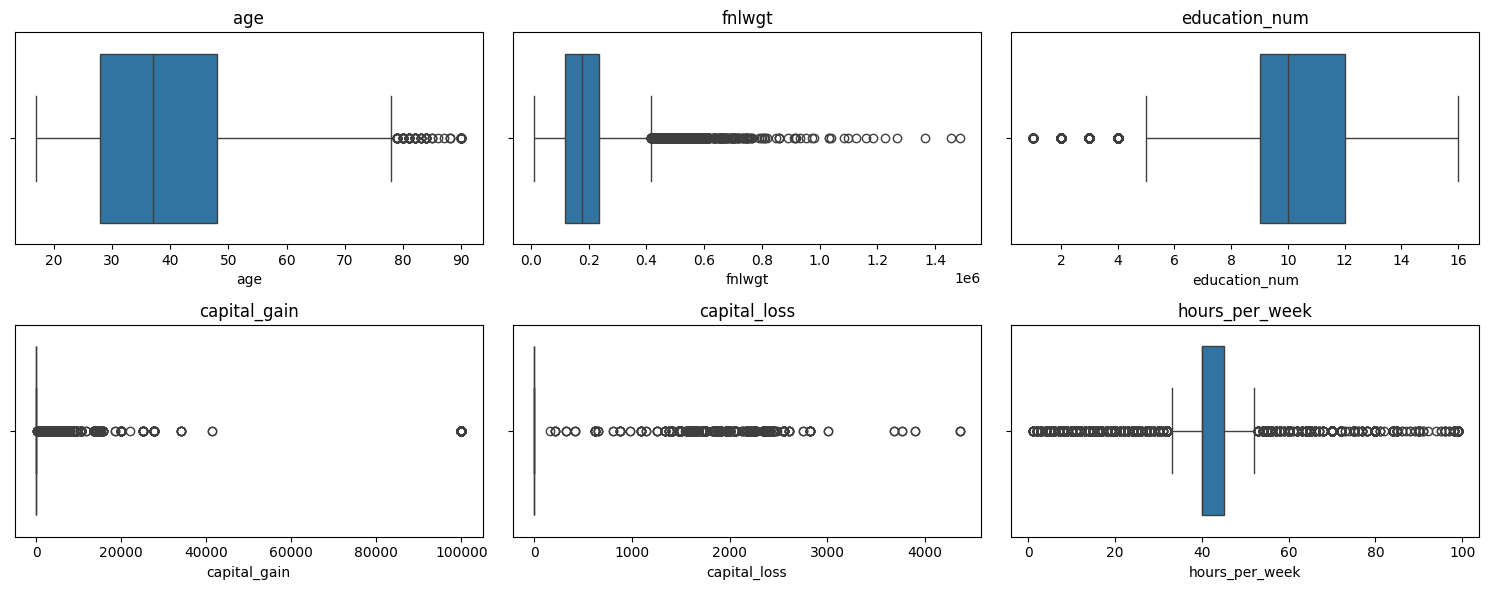

In [76]:
fig,ax = plt.subplots(2,3, figsize=(15,6))
ax = ax.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(x=col, data=df, ax=ax[i],)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

There are many outliers but all those observations does not indicate noise they are actual real values. For age, there are few higher values(80-90) indicating old age individuals. In education num, lower oultiers indicate individuals with lower level of education level. Capital_gain and capital_loss show significant outliers, representing individuals with unusually high profits or losses. These variables are highly skewed and zero-dominated. The majority of individuals have values between 0 and 4000. Most individuals have standard work week between 40-45 hr, while Lower values indicate part-time workers, while higher values (e.g., 80+ hours) reflect overworked individuals

In [23]:
df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])

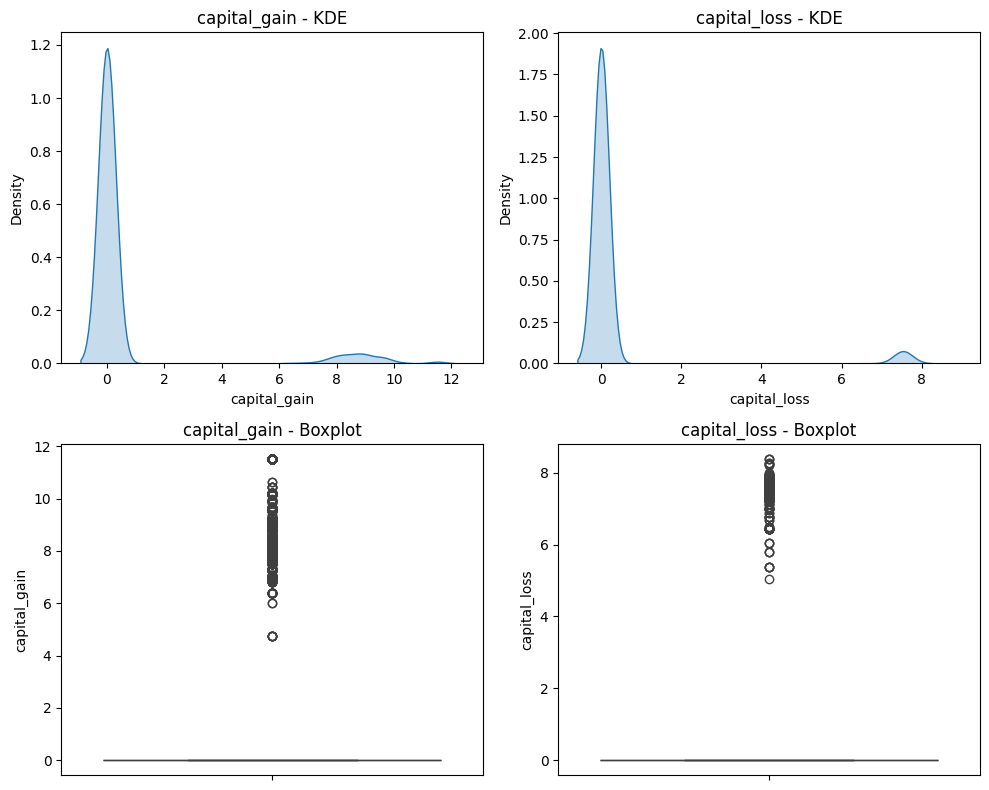

In [24]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
cols = ['capital_gain','capital_loss']

for i,col in enumerate(cols):
    sns.kdeplot(x=df[col], fill=True, ax=ax[0,i])
    ax[0,i].set_title(f'{col} - KDE')
    sns.boxplot(df[col], ax=ax[1,i])
    ax[1,i].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

Log transformation reduces the scale of Capital gain and Capital loss. However, Skewness remains because most values are zero.

In [25]:
df[num_features].corr()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076646,0.036527,0.124183,0.051448,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,-0.004414,-0.009122,-0.018768
education_num,0.036527,-0.043195,1.000000,0.129135,0.077143,0.148123
capital_gain,0.124183,-0.004414,0.129135,1.000000,-0.066161,0.083821
capital_loss,0.051448,-0.009122,0.077143,-0.066161,1.000000,0.051287
hours_per_week,0.068756,-0.018768,0.148123,0.083821,0.051287,1.000000


All features have weak linear relationship with each other.

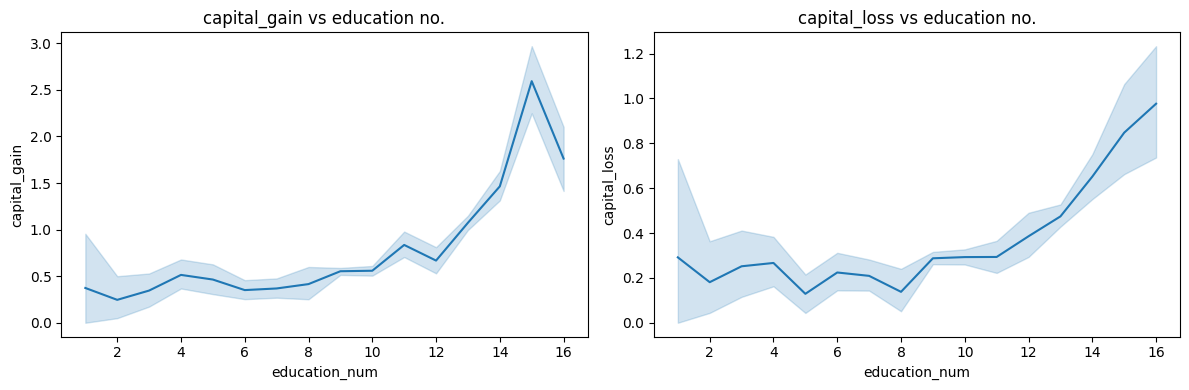

In [27]:
fig,ax = plt.subplots(1,2, figsize=(12,4))
for i,col in enumerate(['capital_gain','capital_loss']):
    sns.lineplot(x=df['education_num'], y=df[col], ax=ax[i])
    ax[i].set_title(f'{col} vs education no.')

plt.tight_layout()
plt.show()

Capital gain generally increases with education level. For individuals having 12-15 years of education it has shown substantial growth. Individuals with ‘Prof-school’ education exhibit the highest capital gains.
Capital loss shows variability among individuals with lower education levels (1–8 years). From secondary education levels (up to ‘12th’), there is an increasing trend in losses.  

Text(0.5, 1.0, 'hours/week vs yrs of education')

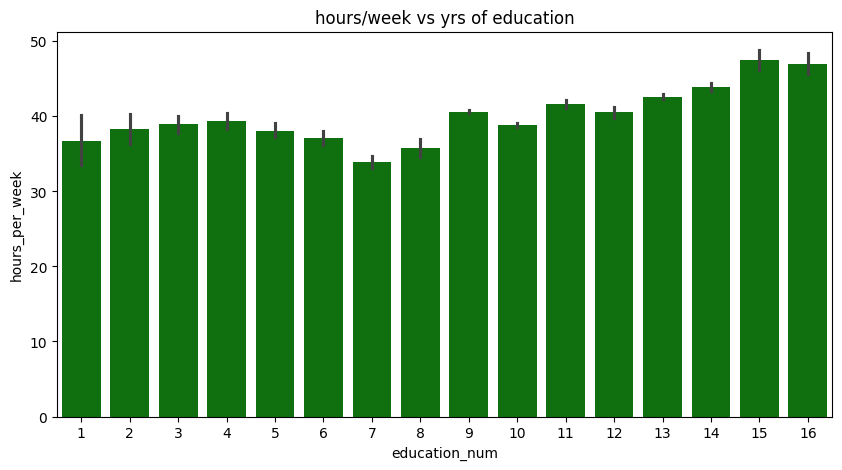

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(x=df['education_num'], y=df['hours_per_week'], color='green')
plt.title('hours/week vs yrs of education')

In [29]:
df['education'].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

Individuals with education levels above 'HS-grade' generally have average working hours slightly above 40 hours per week. The 'Prof-school and 'Doctorate' categories show higher average working hours. However, this may be influenced by smaller sample sizes in these groups.

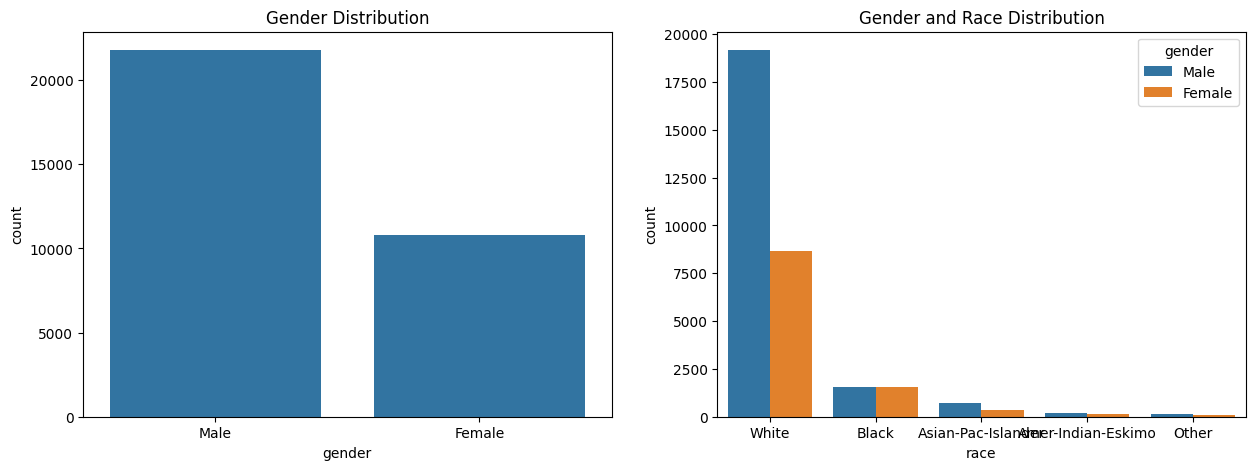

In [30]:
fig,ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(x="gender", data=df, ax=ax[0])
ax[0].set_title("Gender Distribution")
sns.countplot(x="race", hue="gender", data=df, ax=ax[1])
ax[1].set_title("Gender and Race Distribution")
plt.show()

In [31]:
table = df.groupby('race')['income'].value_counts().unstack()
table.style.background_gradient(cmap='Blues')

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,275,36
Asian-Pac-Islander,763,276
Black,2737,387
Other,246,25
White,20699,7117


In [32]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

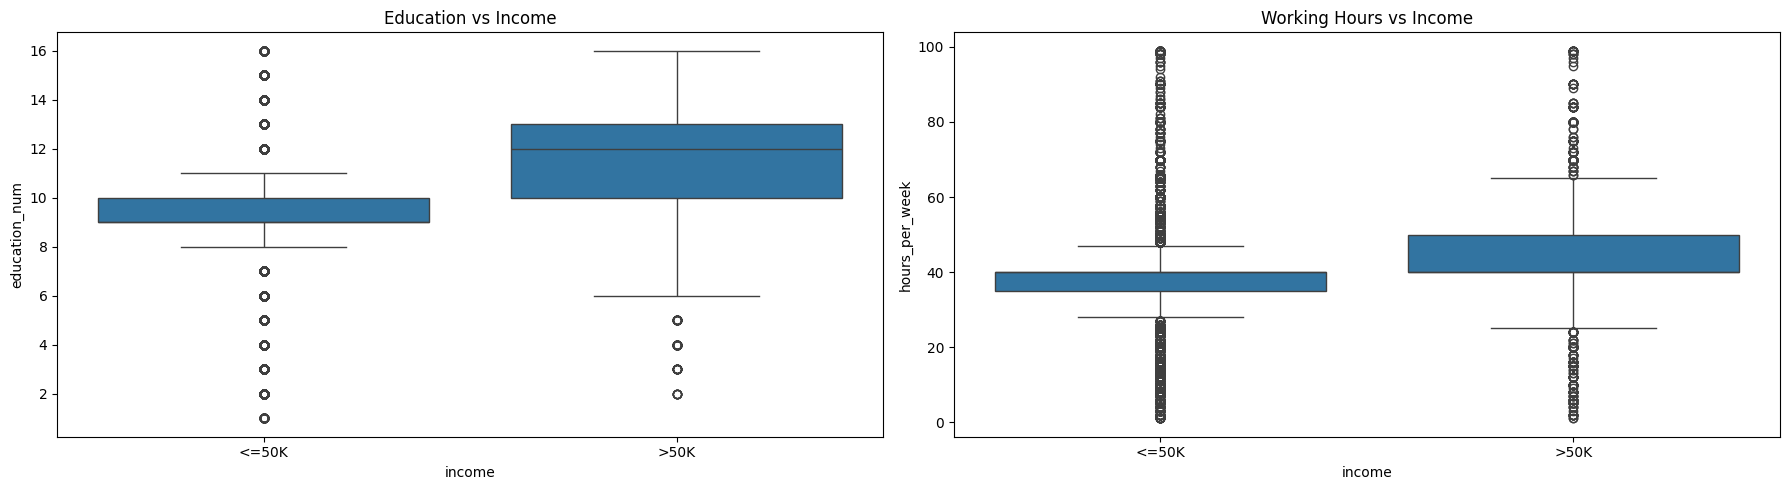

In [33]:
fig,ax = plt.subplots(1,2,figsize=(18,5))
sns.boxplot(x="income", y="education_num", data=df, ax=ax[0])
ax[0].set_title("Education vs Income")

sns.boxplot(x="income", y="hours_per_week", data=df, ax=ax[1])
ax[1].set_title("Working Hours vs Income")

plt.tight_layout()
plt.show()

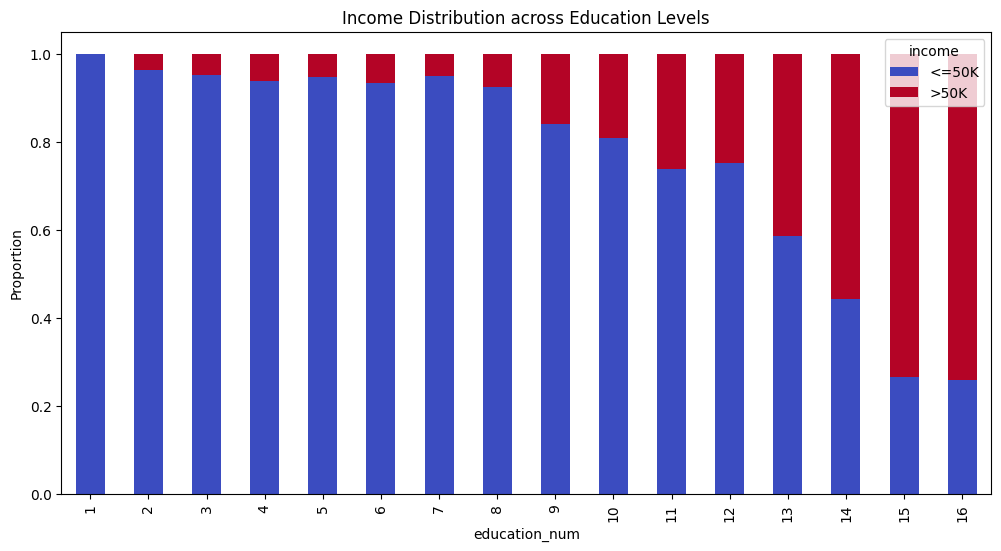

In [34]:
income = pd.crosstab(df['education_num'], df['income'], normalize="index")
income.plot(kind="bar", stacked=True, figsize=(12,6), colormap="coolwarm")
plt.title("Income Distribution across Education Levels")
plt.ylabel("Proportion")
plt.show()

Income distribution shows clear upward trend with increasing education levels. Lower education levels are strongly associated with lower income. While higher education levels (particularly above 12) are associated with a significantly higher proportion of individuals earning >50K.

In [26]:
## Including new feature based on whether person is government employee or not.
df['gov_employee'] = df['workclass'].apply(lambda x : 1 if x.endswith('gov') else 0)

In [27]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income,gov_employee
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40,United-States,<=50K,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40,Cuba,<=50K,0


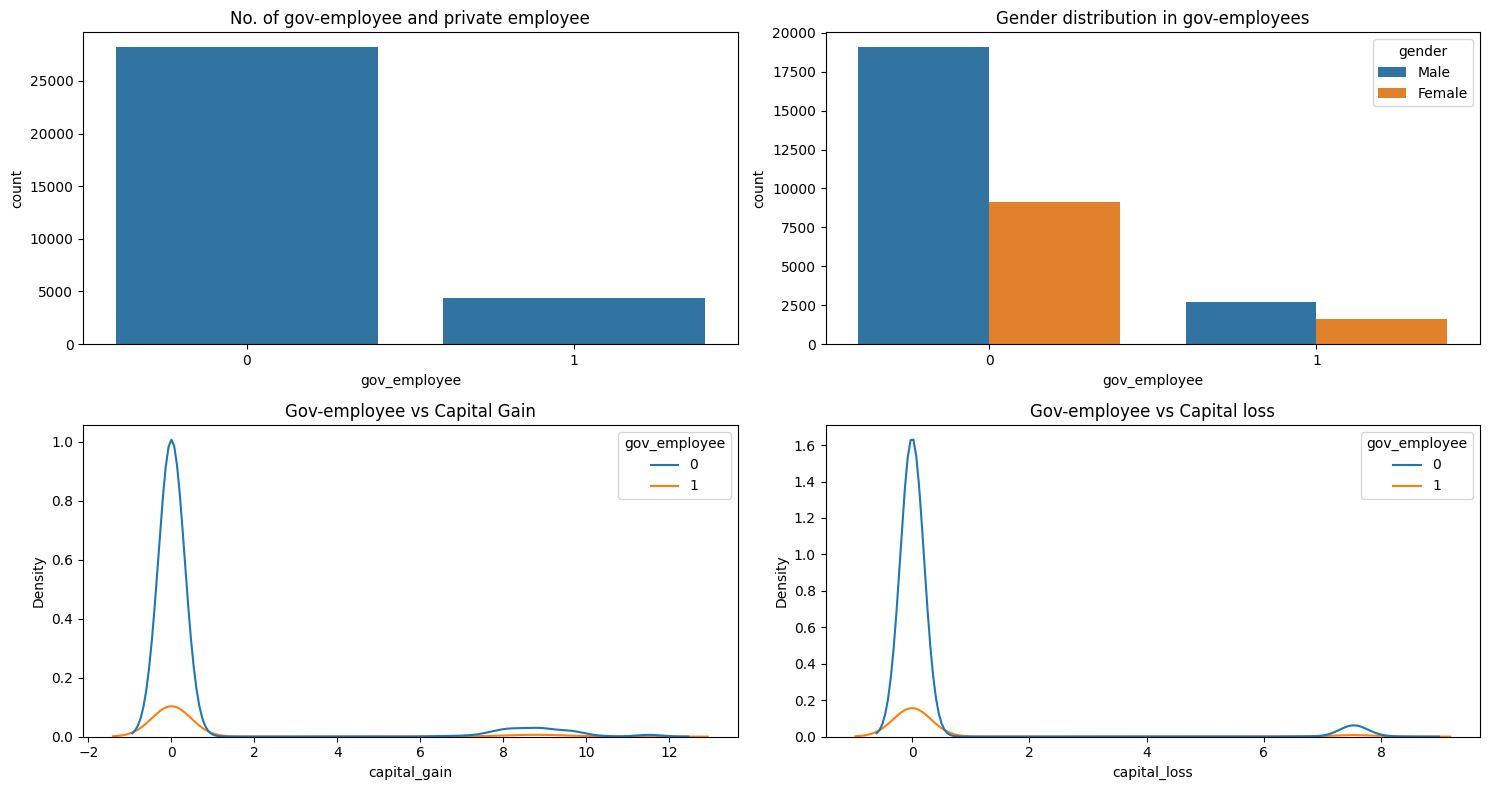

In [28]:
fig,ax = plt.subplots(2,2, figsize=(15,8))
sns.countplot(x=df['gov_employee'], ax=ax[0,0])
ax[0,0].set_title('No. of gov-employee and private employee')
sns.countplot(x=df['gov_employee'], hue=df['gender'], ax=ax[0,1])
ax[0,1].set_title('Gender distribution in gov-employees')
sns.kdeplot(x=df['capital_gain'], hue=df['gov_employee'], ax=ax[1,0])
ax[1,0].set_title('Gov-employee vs Capital Gain')
sns.kdeplot(x=df['capital_loss'], hue=df['gov_employee'], ax=ax[1,1])
ax[1,1].set_title('Gov-employee vs Capital loss')
plt.tight_layout()
plt.show()

The majority of individuals are non-government employees. Capital gain for both groups is concentrated around zero, although some non-government employees have significantly higher capital gains than others. A small number of gov-employees show high capital gain. Similarly, capital loss is concentrated around zero for both groups, with some non-government employees exhibiting higher capital losses than others.

In [29]:
num_features = df.select_dtypes(exclude='object').columns
cat_features = df.select_dtypes(include='object').columns

In [30]:
num_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'gov_employee'],
      dtype='object')

In [31]:
cat_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender', 'native_country', 'income'],
      dtype='object')

In [42]:
## Chi-square test to check whether income differs across categorical features
from scipy.stats import chi2_contingency
features = ['workclass', 'education', 'marital_status', 'occupation','relationship', 'race', 'gender', 'native_country']
summary = {'chi2':[], 'p-value':[], 'cramers_v':[]}
for col in features:
    table = pd.crosstab(df[col], df['income'])
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    cramer_v = np.sqrt(chi2/(n * (min(table.shape) - 1))) if min(table.shape) > 1 else 0
    summary['cramers_v'].append(cramer_v)
    summary['chi2'].append(chi2)
    summary['p-value'].append(p)

summary_df = pd.DataFrame(summary,index=features).sort_values(by='cramers_v', ascending=False)
summary_df

,chi2,p-value,cramers_v
relationship,6699.076897,0.000000e+00,0.453585
marital_status,6517.741654,0.000000e+00,0.447404
education,4429.653302,0.000000e+00,0.368838
occupation,4031.974280,0.000000e+00,0.351892
gender,1517.813409,0.000000e+00,0.215904
workclass,1045.708600,2.026505e-220,0.179208
race,330.920431,2.305961e-70,0.100812
native_country,317.230386,2.211386e-44,0.098705


In [43]:
def interpret(p, v):
    if p < 0.05:
        if v < 0.1:
            return 'sig/weak'
        elif v < 0.3:
            return 'sig/moderate'
        else:
            return 'sig/strong'
    else:
        if v < 0.1:
            return 'not_sig/weak'
        elif v < 0.3:
            return 'not_sig/moderate'
        else:
            return 'not_sig/strong'

In [44]:
summary_df['sig/strength'] = summary_df.apply(lambda row: interpret(row['p-value'], row['cramers_v']), axis=1)
summary_df

,chi2,p-value,cramers_v,sig/strength
relationship,6699.076897,0.000000e+00,0.453585,sig/strong
marital_status,6517.741654,0.000000e+00,0.447404,sig/strong
education,4429.653302,0.000000e+00,0.368838,sig/strong
occupation,4031.974280,0.000000e+00,0.351892,sig/strong
gender,1517.813409,0.000000e+00,0.215904,sig/moderate
workclass,1045.708600,2.026505e-220,0.179208,sig/moderate
race,330.920431,2.305961e-70,0.100812,sig/moderate
native_country,317.230386,2.211386e-44,0.098705,sig/weak


'Native_country' is significant but has weak association with 'income'

In [45]:
from sklearn.feature_selection import mutual_info_classif

# separate feature and target
X1 = df.drop('income', axis=1)
Y1 = df['income'].astype('category').cat.codes

# encode categorical variables
X1_encoded = pd.get_dummies(X1, drop_first=True)

# compute MI
mi = mutual_info_classif(X1_encoded, Y1, random_state=42)

# create series
mi_scores = pd.Series(mi, index=X1_encoded.columns).sort_values(ascending=False)

mi_scores

marital_status_Married-civ-spouse    0.107235
capital_gain                         0.084138
education_num                        0.068474
age                                  0.063319
marital_status_Never-married         0.061278
                                       ...   
native_country_England               0.000000
native_country_France                0.000000
native_country_Guatemala             0.000000
native_country_Haiti                 0.000000
native_country_Yugoslavia            0.000000
Length: 101, dtype: float64

In [46]:
mi_df = mi_scores.reset_index()
mi_df.columns = ['categories', 'mi']
mi_df.head()

,categories,mi
0,marital_status_Married-civ-spouse,0.107235
1,capital_gain,0.084138
2,education_num,0.068474
3,age,0.063319
4,marital_status_Never-married,0.061278


In [ ]:
features = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
            'marital_status', 'occupation', 'relationship', 'race', 'gender',
            'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'gov_employee']

def get_feature(col):
    for f in features:
        if col.startswith(f + '_') or col == f:
            return f
    return col
    
mi_df['feature'] = mi_df['categories'].apply(get_feature)


In [48]:
mi_df.head()

,categories,mi,feature
0,marital_status_Married-civ-spouse,0.107235,marital_status
1,capital_gain,0.084138,capital_gain
2,education_num,0.068474,education
3,age,0.063319,age
4,marital_status_Never-married,0.061278,marital_status


In [49]:
mi_feature = mi_df.groupby('feature')['mi'].sum().sort_values(ascending=False)
mi_feature_df = mi_feature.reset_index()
mi_feature_df.columns = ['features', 'mi']
mi_feature_df

,features,mi
0,marital_status,0.182576
1,education,0.148494
2,relationship,0.084895
3,capital_gain,0.084138
4,occupation,0.070357
5,age,0.063319
6,native_country,0.049879
7,hours_per_week,0.041873
8,capital_loss,0.034149
9,fnlwgt,0.033637


'education','marital_status','relationship' are statistically significant features. They also show strong categorical association (high Cramer's V) and high mutual information with 'income', suggesting that they are important and potentially highly predictive features.

#### Feature importance using Random Forest

In [51]:
df.select_dtypes(include='object').columns

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender', 'native_country', 'income'],
      dtype='object')

In [52]:
numeric_col = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week', 'education_num']
nominal_col = [ 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'gender', 'native_country']
ordinal_col = ['education']
binary_col = ['gov_employee']

In [53]:
X = df.drop('income', axis=1)
y = df['income']

In [54]:
X.shape, y.shape

((32561, 15), (32561,))

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline

In [56]:
preprocessor2 = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_col),
    ('ordinal', OrdinalEncoder(categories=[['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']]), ordinal_col),
    ('numeric', 'passthrough', numeric_col),
    ('binary', 'passthrough', binary_col)
])

le = LabelEncoder()

In [57]:
pipeline = Pipeline([
    ('preprocessor', preprocessor2)
])

In [58]:
X_processed = pipeline.fit_transform(X)
y_processed = le.fit_transform(y)

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_processed, y_processed)

RandomForestClassifier()

In [60]:
feature_names = preprocessor2.get_feature_names_out()
importances = rf.feature_importances_

In [61]:
feature_imp = {'feature':[], 'FI':[]}
all_features = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'gov_employee']
for name, importance in zip(feature_names, importances):
    for f in all_features:
        if (name.startswith('nominal__' + f + '_') or name.endswith('__' + f)):
            feature_imp['feature'].append(f)
            feature_imp['FI'].append(importance)
            break

In [62]:
FI_df = pd.DataFrame(feature_imp)
FI_summary = (FI_df.groupby('feature')['FI'].sum().sort_values(ascending=False))
FI_summary = FI_summary.reset_index()
FI_summary

,feature,FI
0,fnlwgt,0.164115
1,age,0.153630
2,marital_status,0.111074
3,capital_gain,0.097828
4,hours_per_week,0.084453
5,occupation,0.079207
6,education,0.068491
7,education_num,0.063533
8,relationship,0.051458
9,capital_loss,0.032589


In [63]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_cv = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1)
random_cv.fit(X_processed, y_processed)
print('------{Best parameters}--------')
print(random_cv.best_params_)
print('------{Best score}--------')
print(random_cv.best_score_)

------{Best parameters}--------
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
------{Best score}--------
0.8635485690874912


In [64]:
rf = RandomForestClassifier(n_estimators=100, min_samples_split=5, min_samples_leaf=2, max_features='log2', max_depth=None, bootstrap=False)
rf.fit(X_processed, y_processed)

RandomForestClassifier(bootstrap=False, max_features='log2', min_samples_leaf=2,
                       min_samples_split=5)

In [65]:
feature_names = preprocessor2.get_feature_names_out()
importances = rf.feature_importances_

feature_imp = {'feature':[], 'FI':[]}
all_features = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'gov_employee']
for name, importance in zip(feature_names, importances):
    for f in all_features:
        if (name.startswith('nominal__' + f + '_') or name.endswith('__' + f)):
            feature_imp['feature'].append(f)
            feature_imp['FI'].append(importance)
            break

FI_df = pd.DataFrame(feature_imp)
FI_summary = (FI_df.groupby('feature')['FI'].sum().sort_values(ascending=False))
FI_summary = FI_summary.reset_index()
FI_summary

,feature,FI
0,marital_status,0.192880
1,capital_gain,0.143707
2,age,0.096077
3,education,0.093672
4,education_num,0.092219
5,relationship,0.083662
6,occupation,0.083021
7,hours_per_week,0.057940
8,fnlwgt,0.043987
9,capital_loss,0.036038


'race' and 'gov_employee' are statistically significant with respect to 'income', but they show very weak association (low Cramer's V), low mutual information, and very low feature importance in the Random Forest model. This suggests that 'race' and 'gov_employee' has little contribution in predicting income and may be considered for removal from the model.

In [33]:
df.drop(['race', 'gov_employee', 'fnlwgt'], axis=1, inplace=True)

In [34]:
df.shape

(32561, 13)

#### Preprocessing

In [35]:
numeric_col = ['age', 'capital_gain', 'capital_loss', 'hours_per_week', 'education_num']
nominal_col = ['workclass', 'marital_status', 'occupation', 'relationship', 'gender', 'native_country']
ordinal_col = ['education']

In [38]:
preprocessor3 = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_col),
    ('ordinal', OrdinalEncoder(categories=[['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']]), ordinal_col),
    ('numeric', 'passthrough', numeric_col)
])

le = LabelEncoder()

In [39]:
pipeline = Pipeline([
    ('preprocessor', preprocessor3)
])

In [40]:
X = df.drop('income', axis=1)
y = df['income']

In [41]:
X_processed = pipeline.fit_transform(X)
y_processed = le.fit_transform(y)

In [43]:
import joblib

In [45]:
joblib.dump(le, "target_encoder.pkl")

['target_encoder.pkl']

In [44]:
joblib.dump(pipeline, "model_pipeline.pkl")

['model_pipeline.pkl']

In [78]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#### Model Building

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_processed, y_processed, test_size=0.3)

In [80]:
def evaluate_model(true, pred):
    accuracy = accuracy_score(true, pred)
    precision = precision_score(true, pred, average='binary')
    recall = recall_score(true, pred, average='binary')
    f1 = f1_score(true, pred, average='binary')

    return accuracy, precision, recall, f1

In [81]:
models = {
    'LogisticRegression': LogisticRegression(),
    'Ridge': RidgeClassifier(),
    'RandomForest' : RandomForestClassifier(),
    'GradientBoost': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'CatBoost': CatBoostClassifier(),
    'XGBoost': XGBClassifier(),
    'Lightgbm': LGBMClassifier()
}

summary = {'model':[], 'train_accuracy':[], 'test_accuracy':[], 'train_precision':[], 'test_precision':[], 'train_recall':[], 'test_recall':[], 'train_f1':[], 'test_f1':[]}

for i in range(len(models.keys())):
    
    model = list(models.values())[i]
    model_name = list(models.keys())[i]
    summary['model'].append(model_name)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train set
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train, y_train_pred)
    summary['train_accuracy'].append(train_accuracy)
    summary['train_precision'].append(train_precision)
    summary['train_recall'].append(train_recall)
    summary['train_f1'].append(train_f1)

    # Evaluate Test set
    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(y_test, y_test_pred)
    summary['test_accuracy'].append(test_accuracy)
    summary['test_precision'].append(test_precision)
    summary['test_recall'].append(test_recall)
    summary['test_f1'].append(test_f1)

    # Print model name
    print(list(models.keys())[i])

    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print("- Precision: {:.4f}".format(train_precision))
    print("- Recall: {:.4f}".format(train_recall))
    print("- F1 Score: {:.4f}".format(train_f1))

    print('----------------------------------')

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(test_accuracy))
    print("- Precision: {:.4f}".format(test_precision))
    print("- Recall: {:.4f}".format(test_recall))
    print("- F1 Score: {:.4f}".format(test_f1))

    print('=' * 35)
    print('\n')

LogisticRegression
Model performance for Training set
- Accuracy: 0.8449
- Precision: 0.7195
- Recall: 0.5926
- F1 Score: 0.6499
----------------------------------
Model performance for Test set
- Accuracy: 0.8447
- Precision: 0.7130
- Recall: 0.5716
- F1 Score: 0.6345


Ridge
Model performance for Training set
- Accuracy: 0.8425
- Precision: 0.7384
- Recall: 0.5445
- F1 Score: 0.6268
----------------------------------
Model performance for Test set
- Accuracy: 0.8437
- Precision: 0.7347
- Recall: 0.5278
- F1 Score: 0.6143


RandomForest
Model performance for Training set
- Accuracy: 0.9773
- Precision: 0.9631
- Recall: 0.9427
- F1 Score: 0.9528
----------------------------------
Model performance for Test set
- Accuracy: 0.8498
- Precision: 0.7147
- Recall: 0.6046
- F1 Score: 0.6551


GradientBoost
Model performance for Training set
- Accuracy: 0.8673
- Precision: 0.7971
- Recall: 0.6086
- F1 Score: 0.6902
----------------------------------
Model performance for Test set
- Accuracy: 0

In [82]:
summary_df = pd.DataFrame(summary)
summary_df

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
0,LogisticRegression,0.844902,0.844713,0.719518,0.713048,0.592559,0.571615,0.649896,0.634546
1,Ridge,0.842489,0.843689,0.738428,0.734743,0.544519,0.527778,0.626819,0.614297
2,RandomForest,0.977317,0.849831,0.963100,0.714726,0.942749,0.604601,0.952816,0.655067
3,GradientBoost,0.867278,0.868871,0.797067,0.801059,0.608633,0.590712,0.690220,0.679990
4,AdaBoost,0.859205,0.865186,0.764666,0.776781,0.607369,0.601128,0.677001,0.677759
5,DecisionTree,0.977580,0.821988,0.984948,0.629647,0.921799,0.595486,0.952328,0.612090
6,KNN,0.869384,0.819531,0.746438,0.621464,0.700199,0.600694,0.722579,0.610903
7,SVM,0.837136,0.836728,0.765957,0.754487,0.474625,0.456163,0.586084,0.568569
8,CatBoost,0.890839,0.878084,0.828061,0.802281,0.694961,0.641059,0.755695,0.712666
9,XGBoost,0.893164,0.876344,0.827077,0.788421,0.708326,0.650174,0.763109,0.712655


CatBoost, XGBoost, and LightGBM show strong generalization performance with high F1-score, precision, and recall on the test set. In contrast, Random Forest and Decision Tree exhibit severe overfitting due to a large gap between training and testing performance.

#### Hyperparameter Tuning

In [83]:
cat_params = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

lgbm_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50, 100],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [84]:
randomcv_models = [
    ('CatBoost', CatBoostClassifier(), cat_params),
    ('XGBoost', XGBClassifier(), xgb_params),
    ('LightGBM', LGBMClassifier(), lgbm_params)
]

In [85]:
from sklearn.model_selection import RandomizedSearchCV

In [86]:
model_para = {}
for name, model, param in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=param, n_iter=50, cv=5, verbose=2, n_jobs=-1)
    randomcv.fit(X_train, y_train)
    model_para[name] = randomcv.best_params_

for model_name in model_para.keys():
    print(f'------Best param for {model_name}------')
    print(model_para[model_name])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0:	learn: 0.6014600	total: 14.9ms	remaining: 4.46s
1:	learn: 0.5282570	total: 27.8ms	remaining: 4.13s
2:	learn: 0.4781628	total: 41.9ms	remaining: 4.15s
3:	learn: 0.4400203	total: 59.8ms	remaining: 4.42s
4:	learn: 0.4124253	total: 75.5ms	remaining: 4.46s
5:	learn: 0.3919042	total: 89.9ms	remaining: 4.41s
6:	learn: 0.3742432	total: 105ms	remaining: 4.38s
7:	learn: 0.3624867	total: 119ms	remaining: 4.36s
8:	learn: 0.3536429	total: 134ms	remaining: 4.33s
9:	learn: 0.3470550	total: 148ms	remaining: 4.28s
10:	learn: 0.3403437	total: 162ms	remaining: 4.26s
11:	learn: 0.3362552	total: 177ms	remaining: 4.25s
12:	learn: 0.3318498	total: 191ms	remaining: 4.21s
13:	learn: 0.3280938	total: 204ms	remaining: 4.16s
14:	learn: 0.3248439	total: 219ms	remaining: 4.17s
15:	learn: 0.3225095	total: 238ms	remaining: 4.22s
16:	learn: 0.3206896	total: 254ms	remaining: 4.23s
17:	learn: 0.3191508	total: 271ms	remaining: 4.24s
18:	learn: 0.3168990	tot

In [87]:
models = {
    'CatBoost': CatBoostClassifier(subsample=0.8, learning_rate=0.1, l2_leaf_reg=3, iterations=300, depth=6),
    'XGBoost': XGBClassifier(subsample=0.8, n_estimators=300, max_depth=3, learning_rate=0.1, gamma=0.3, colsample_bytree=0.7),
    'LightGBM': LGBMClassifier(subsample=0.8, num_leaves=31, n_estimators=200, max_depth=-1, learning_rate=0.05, colsample_bytree=0.7)
}

summary = {'model':[], 'train_accuracy':[], 'test_accuracy':[], 'train_precision':[], 'test_precision':[], 'train_recall':[], 'test_recall':[], 'train_f1':[], 'test_f1':[]}

for i in range(len(models.keys())):
    
    model = list(models.values())[i]
    model_name = list(models.keys())[i]
    summary['model'].append(model_name)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train set
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train, y_train_pred)
    summary['train_accuracy'].append(train_accuracy)
    summary['train_precision'].append(train_precision)
    summary['train_recall'].append(train_recall)
    summary['train_f1'].append(train_f1)

    # Evaluate Test set
    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(y_test, y_test_pred)
    summary['test_accuracy'].append(test_accuracy)
    summary['test_precision'].append(test_precision)
    summary['test_recall'].append(test_recall)
    summary['test_f1'].append(test_f1)

    # Print model name
    print(list(models.keys())[i])

    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print("- Precision: {:.4f}".format(train_precision))
    print("- Recall: {:.4f}".format(train_recall))
    print("- F1 Score: {:.4f}".format(train_f1))

    print('----------------------------------')

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(test_accuracy))
    print("- Precision: {:.4f}".format(test_precision))
    print("- Recall: {:.4f}".format(test_recall))
    print("- F1 Score: {:.4f}".format(test_f1))

    print('=' * 35)
    print('\n')

0:	learn: 0.6014600	total: 7.53ms	remaining: 2.25s
1:	learn: 0.5282570	total: 16.2ms	remaining: 2.41s
2:	learn: 0.4781628	total: 22.9ms	remaining: 2.27s
3:	learn: 0.4400203	total: 33ms	remaining: 2.44s
4:	learn: 0.4124253	total: 41.6ms	remaining: 2.46s
5:	learn: 0.3919042	total: 49ms	remaining: 2.4s
6:	learn: 0.3742432	total: 56.1ms	remaining: 2.35s
7:	learn: 0.3624867	total: 64.6ms	remaining: 2.36s
8:	learn: 0.3536429	total: 73.8ms	remaining: 2.38s
9:	learn: 0.3470550	total: 84.6ms	remaining: 2.45s
10:	learn: 0.3403437	total: 92.8ms	remaining: 2.44s
11:	learn: 0.3362552	total: 101ms	remaining: 2.42s
12:	learn: 0.3318498	total: 110ms	remaining: 2.43s
13:	learn: 0.3280938	total: 118ms	remaining: 2.4s
14:	learn: 0.3248439	total: 126ms	remaining: 2.4s
15:	learn: 0.3225095	total: 134ms	remaining: 2.38s
16:	learn: 0.3206896	total: 144ms	remaining: 2.39s
17:	learn: 0.3191508	total: 152ms	remaining: 2.38s
18:	learn: 0.3168990	total: 161ms	remaining: 2.38s
19:	learn: 0.3153537	total: 170ms	rem

In [88]:
summary_df = pd.DataFrame(summary)
summary_df

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
0,CatBoost,0.887110,0.879414,0.821336,0.809341,0.684125,0.639323,0.746477,0.714355
1,XGBoost,0.876536,0.877777,0.797596,0.804610,0.659021,0.636285,0.721717,0.710616
2,LightGBM,0.882503,0.879107,0.806562,0.799786,0.679249,0.650174,0.737451,0.717261


In [89]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [91]:
train_roc_auc = []
test_roc_auc = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    #Predict Probability
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    #ROC-AUC scores
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    train_roc_auc.append(train_auc)
    test_roc_auc.append(test_auc)

summary_df['train_roc_auc'] = train_roc_auc
summary_df['test_roc_auc'] = test_roc_auc

0:	learn: 0.6014600	total: 9.57ms	remaining: 2.86s
1:	learn: 0.5282570	total: 16.1ms	remaining: 2.4s
2:	learn: 0.4781628	total: 24.4ms	remaining: 2.42s
3:	learn: 0.4400203	total: 31.7ms	remaining: 2.35s
4:	learn: 0.4124253	total: 41.3ms	remaining: 2.44s
5:	learn: 0.3919042	total: 48.2ms	remaining: 2.36s
6:	learn: 0.3742432	total: 56.5ms	remaining: 2.36s
7:	learn: 0.3624867	total: 63.1ms	remaining: 2.3s
8:	learn: 0.3536429	total: 72.2ms	remaining: 2.33s
9:	learn: 0.3470550	total: 80.7ms	remaining: 2.34s
10:	learn: 0.3403437	total: 89.2ms	remaining: 2.34s
11:	learn: 0.3362552	total: 98.4ms	remaining: 2.36s
12:	learn: 0.3318498	total: 107ms	remaining: 2.36s
13:	learn: 0.3280938	total: 116ms	remaining: 2.37s
14:	learn: 0.3248439	total: 126ms	remaining: 2.4s
15:	learn: 0.3225095	total: 134ms	remaining: 2.38s
16:	learn: 0.3206896	total: 143ms	remaining: 2.39s
17:	learn: 0.3191508	total: 152ms	remaining: 2.38s
18:	learn: 0.3168990	total: 160ms	remaining: 2.36s
19:	learn: 0.3153537	total: 168m

In [92]:
summary_df

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,CatBoost,0.887110,0.879414,0.821336,0.809341,0.684125,0.639323,0.746477,0.714355,0.945661,0.933256
1,XGBoost,0.876536,0.877777,0.797596,0.804610,0.659021,0.636285,0.721717,0.710616,0.934549,0.932517
2,LightGBM,0.882503,0.879107,0.806562,0.799786,0.679249,0.650174,0.737451,0.717261,0.943926,0.932399


Among all tunned models, CatBoost demonstrates the best generalization performance, achieving the highest precision, recall, F1-score, and ROC-AUC score on the test set among all evaluated models.

#### Final Model

In [93]:
model = CatBoostClassifier(subsample=0.8, learning_rate=0.1, l2_leaf_reg=3, iterations=300, depth=6)
model.fit(X_train, y_train)

0:	learn: 0.6014600	total: 14ms	remaining: 4.19s
1:	learn: 0.5282570	total: 21.7ms	remaining: 3.24s
2:	learn: 0.4781628	total: 27.9ms	remaining: 2.77s
3:	learn: 0.4400203	total: 35.1ms	remaining: 2.6s
4:	learn: 0.4124253	total: 43.7ms	remaining: 2.58s
5:	learn: 0.3919042	total: 50.7ms	remaining: 2.48s
6:	learn: 0.3742432	total: 59.5ms	remaining: 2.49s
7:	learn: 0.3624867	total: 67.9ms	remaining: 2.48s
8:	learn: 0.3536429	total: 76.1ms	remaining: 2.46s
9:	learn: 0.3470550	total: 84.4ms	remaining: 2.45s
10:	learn: 0.3403437	total: 95.1ms	remaining: 2.5s
11:	learn: 0.3362552	total: 104ms	remaining: 2.48s
12:	learn: 0.3318498	total: 111ms	remaining: 2.45s
13:	learn: 0.3280938	total: 120ms	remaining: 2.44s
14:	learn: 0.3248439	total: 127ms	remaining: 2.42s
15:	learn: 0.3225095	total: 138ms	remaining: 2.45s
16:	learn: 0.3206896	total: 146ms	remaining: 2.43s
17:	learn: 0.3191508	total: 155ms	remaining: 2.43s
18:	learn: 0.3168990	total: 163ms	remaining: 2.41s
19:	learn: 0.3153537	total: 172ms	

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.1, subsample=0.8)

In [94]:
joblib.dump(model, "final_model.pkl")

['final_model.pkl']

#### Performance on Test Data

In [139]:
test_data = pd.read_csv("../data/adult.test", index_col=False, names=['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','gender','capital_gain','capital_loss','hours_per_week','native_country', 'income'])
test_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
0,|1x3 Cross validator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.


In [140]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16282 entries, 0 to 16281
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             16282 non-null  object 
 1   workclass       16281 non-null  object 
 2   fnlwgt          16281 non-null  float64
 3   education       16281 non-null  object 
 4   education_num   16281 non-null  float64
 5   marital_status  16281 non-null  object 
 6   occupation      16281 non-null  object 
 7   relationship    16281 non-null  object 
 8   race            16281 non-null  object 
 9   gender          16281 non-null  object 
 10  capital_gain    16281 non-null  float64
 11  capital_loss    16281 non-null  float64
 12  hours_per_week  16281 non-null  float64
 13  native_country  16281 non-null  object 
 14  income          16281 non-null  object 
dtypes: float64(5), object(10)
memory usage: 1.9+ MB


In [141]:
df_test = test_data.copy()
df_test.shape 

(16282, 15)

In [142]:
df_test.drop(0, axis=0, inplace=True)

In [143]:
df_test['age'] = pd.to_numeric(df_test['age'], errors='coerce')

In [144]:
df_test['age'].dtype

dtype('int64')

In [145]:
## Removing leading spaces from object columns
obj_cols = df_test.select_dtypes(include='object')
df_test[obj_cols.columns] = obj_cols.apply(lambda x:x.str.lstrip())

## Replacing '?' with unknown
for col in ['workclass', 'occupation','native_country']:
    df_test[col].replace('?', 'Unknown', inplace=True)

## imputation
preprocessor1.transform(df_test)

## applying log transformation to Capital_gain and Capital_loss
df_test['capital_gain'] = np.log1p(df_test['capital_gain'])
df_test['capital_loss'] = np.log1p(df_test['capital_loss'])

In [146]:
df_test['income'].unique()

array(['<=50K.', '>50K.'], dtype=object)

In [147]:
df_test['income'] = df_test['income'].str.strip('.')

In [148]:
df_test['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [150]:
X = df_test.drop('income', axis=1)
y = df_test['income']

In [151]:
X_test = pipeline.transform(X)
y_test = le.transform(y)

In [152]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [153]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8718137706529083
Precision: 0.7792950142902508
Recall: 0.6380655226209049
F1 Score: 0.7016440314510365
ROC-AUC: 0.9258308362089208


In [154]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     12435
           1       0.78      0.64      0.70      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.79      0.81     16281
weighted avg       0.87      0.87      0.87     16281



In [156]:
from sklearn.metrics import confusion_matrix

<Axes: >

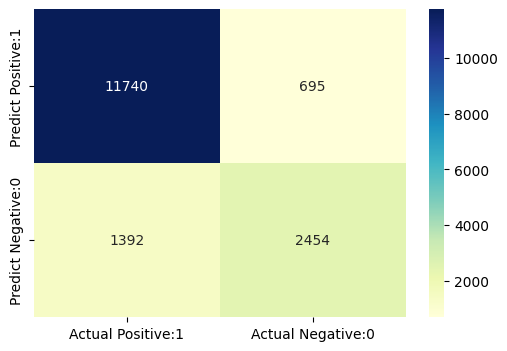

In [158]:
plt.figure(figsize=(6,4))
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

The confusion matrix indicates that the model correctly classifies the majority of income groups with relatively few false positive predictions.
Overall, CatBoost is the most suitable model for predicting income classification (<=50K vs >50K) among all evaluated models.